In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from pathlib import Path

candidate_paths = [
    Path("../data/fraudTrain.csv"),
    Path("data/fraudTrain.csv"),
    Path("../../data/fraudTrain.csv"),
    Path("/content/fraudTrain.csv"),
]

train_path = next((p for p in candidate_paths if p.exists()), None)

if train_path is None:
    print("cwd:", Path.cwd())
    raise FileNotFoundError("fraudTrain.csv를 찾지 못함")

df = pd.read_csv(train_path)


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [28]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [29]:
df.shape

(1296675, 23)

In [30]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [31]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Unnamed: 0             1296675 non-null  int64         
 1   trans_date_trans_time  1296675 non-null  datetime64[ns]
 2   cc_num                 1296675 non-null  int64         
 3   merchant               1296675 non-null  object        
 4   category               1296675 non-null  object        
 5   amt                    1296675 non-null  float64       
 6   first                  1296675 non-null  object        
 7   last                   1296675 non-null  object        
 8   gender                 1296675 non-null  object        
 9   street                 1296675 non-null  object        
 10  city                   1296675 non-null  object        
 11  state                  1296675 non-null  object        
 12  zip                    12966

In [33]:
df.describe()

,Unnamed: 0,trans_date_trans_time,cc_num,amt,zip,lat,long,city_pop,dob,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,2019-10-03 12:47:28.070214144,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1973-10-03 19:02:55.017178512,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
min,0.000000e+00,2019-01-01 00:00:18,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1924-10-30 00:00:00,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,2019-06-03 19:12:22.500000,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1962-08-13 00:00:00,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,2019-10-03 07:35:47,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1975-11-30 00:00:00,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,2020-01-28 15:02:55.500000,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1987-02-22 00:00:00,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,2020-06-21 12:13:37,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,2005-01-29 00:00:00,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00
std,3.743180e+05,NaN,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,NaN,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02


In [34]:
df.describe(include="object")

,merchant,category,first,last,gender,street,city,state,job,trans_num
count,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675,1296675
unique,693,14,352,481,2,983,894,51,494,1296675
top,fraud_Kilback LLC,gas_transport,Christopher,Smith,F,0069 Robin Brooks Apt. 695,Birmingham,TX,Film/video editor,0b242abb623afc578575680df30655b9
freq,4403,131659,26669,28794,709863,3123,5617,94876,9779,1


In [35]:
df.drop(columns="Unnamed: 0")

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [36]:
import pandas as pd

df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

In [37]:
# 시작일과 종료일 확인
start_date = df["trans_date_trans_time"].min()
end_date = df["trans_date_trans_time"].max()

print("데이터 시작일 :", start_date)
print("데이터 종료일 :", end_date)
print("총 기간 :", end_date - start_date)

데이터 시작일 : 2019-01-01 00:00:18
데이터 종료일 : 2020-06-21 12:13:37
총 기간 : 537 days 12:13:19


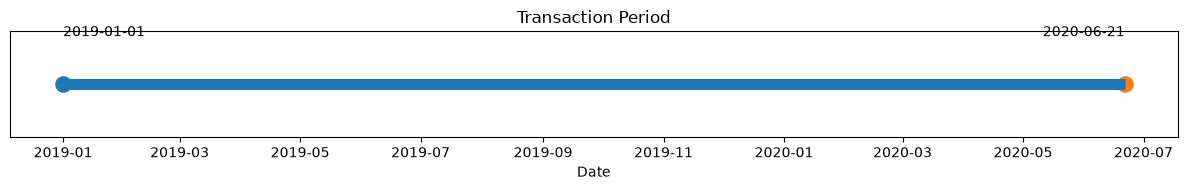

In [38]:
import matplotlib.pyplot as plt

start = df["trans_date_trans_time"].min()
end = df["trans_date_trans_time"].max()

plt.figure(figsize=(12,2))

plt.hlines(y=1, xmin=start, xmax=end, linewidth=8)

plt.scatter(start,1,s=120)
plt.scatter(end,1,s=120)

plt.text(start,1.05,start.strftime('%Y-%m-%d'),ha='left')
plt.text(end,1.05,end.strftime('%Y-%m-%d'),ha='right')

plt.yticks([])
plt.title("Transaction Period")
plt.xlabel("Date")

plt.tight_layout()
plt.show()


In [39]:
df["year_month"] = df["trans_date_trans_time"].dt.to_period("M")

monthly_tx = df.groupby("year_month").size()

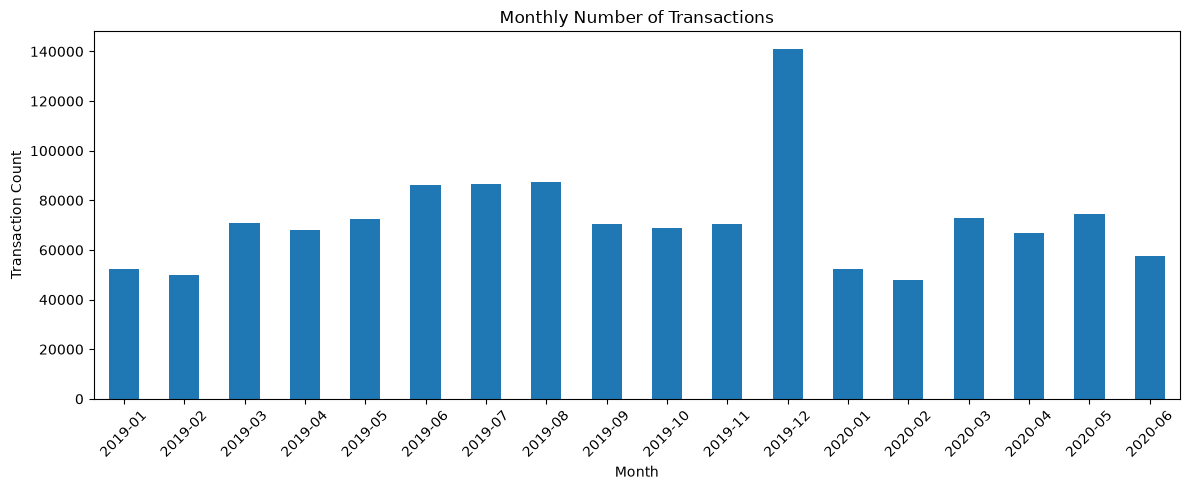

In [40]:
plt.figure(figsize=(12,5))

monthly_tx.plot(kind="bar")

plt.title("Monthly Number of Transactions")
plt.xlabel("Month")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
monthly_tx_df = (
    df.groupby("year_month")
      .size()
      .reset_index(name="transaction_count")
)

monthly_tx_df["percentage"] = (
    monthly_tx_df["transaction_count"]
    / monthly_tx_df["transaction_count"].sum()
    * 100
).round(2)

monthly_tx_df

,year_month,transaction_count,percentage
0,2019-01,52525,4.05
1,2019-02,49866,3.85
2,2019-03,70939,5.47
3,2019-04,68078,5.25
4,2019-05,72532,5.59
5,2019-06,86064,6.64
6,2019-07,86596,6.68
7,2019-08,87359,6.74
8,2019-09,70652,5.45
9,2019-10,68758,5.30


In [42]:
monthly_fraud = (
    df[df["is_fraud"]==1]
    .groupby("year_month")
    .size()
)

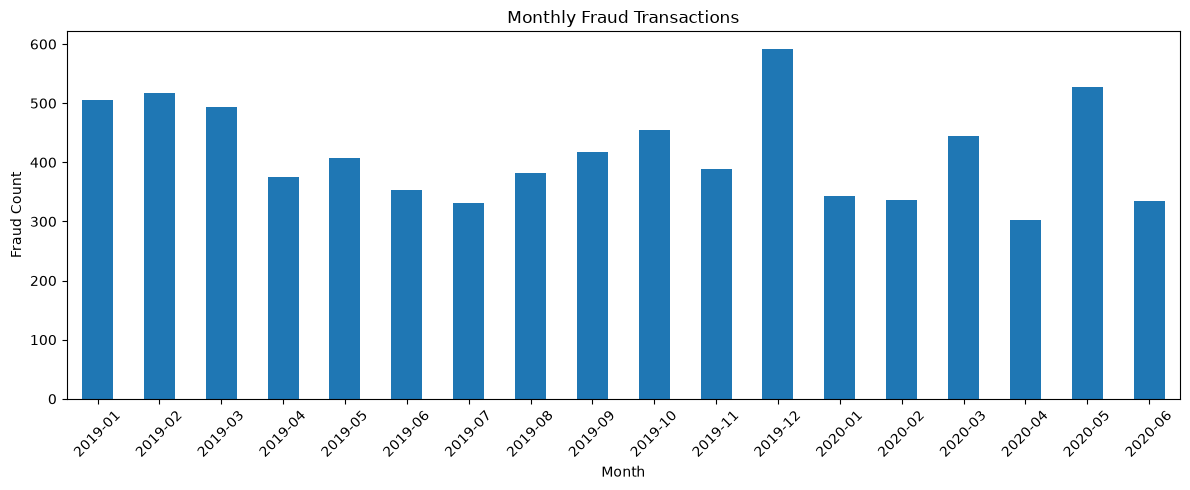

In [43]:
plt.figure(figsize=(12,5))

monthly_fraud.plot(kind="bar")

plt.title("Monthly Fraud Transactions")
plt.xlabel("Month")
plt.ylabel("Fraud Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
# 월별 사기 거래만 추출
monthly_fraud_df = (
    df[df["is_fraud"] == 1]
    .groupby("year_month")
    .size()
    .reset_index(name="fraud_count")
)

monthly_fraud_df

,year_month,fraud_count
0,2019-01,506
1,2019-02,517
2,2019-03,494
3,2019-04,376
4,2019-05,408
5,2019-06,354
6,2019-07,331
7,2019-08,382
8,2019-09,418
9,2019-10,454


In [45]:
# 월별 전체 거래 건수
monthly_total = (
    df.groupby("year_month")
      .size()
      .reset_index(name="total_transactions")
)

# 월별 이상거래 건수
monthly_fraud = (
    df[df["is_fraud"] == 1]
      .groupby("year_month")
      .size()
      .reset_index(name="fraud_transactions")
)

# 병합
monthly_summary = monthly_total.merge(
    monthly_fraud,
    on="year_month",
    how="left"
)

# 이상거래가 없는 월은 0으로 처리
monthly_summary["fraud_transactions"] = (
    monthly_summary["fraud_transactions"]
    .fillna(0)
    .astype(int)
)

# 이상거래 비율(%)
monthly_summary["fraud_rate(%)"] = (
    monthly_summary["fraud_transactions"]
    / monthly_summary["total_transactions"]
    * 100
).round(3)

monthly_summary

,year_month,total_transactions,fraud_transactions,fraud_rate(%)
0,2019-01,52525,506,0.963
1,2019-02,49866,517,1.037
2,2019-03,70939,494,0.696
3,2019-04,68078,376,0.552
4,2019-05,72532,408,0.563
5,2019-06,86064,354,0.411
6,2019-07,86596,331,0.382
7,2019-08,87359,382,0.437
8,2019-09,70652,418,0.592
9,2019-10,68758,454,0.660


In [46]:
monthly_summary['year_month'] = monthly_summary['year_month'].astype(str)
display(monthly_summary)


,year_month,total_transactions,fraud_transactions,fraud_rate(%)
0,2019-01,52525,506,0.963
1,2019-02,49866,517,1.037
2,2019-03,70939,494,0.696
3,2019-04,68078,376,0.552
4,2019-05,72532,408,0.563
5,2019-06,86064,354,0.411
6,2019-07,86596,331,0.382
7,2019-08,87359,382,0.437
8,2019-09,70652,418,0.592
9,2019-10,68758,454,0.660


In [47]:
df["hour"] = df["trans_date_trans_time"].dt.hour

hour_fraud = (
    df[df["is_fraud"]==1]
    .groupby("hour")
    .size()
)

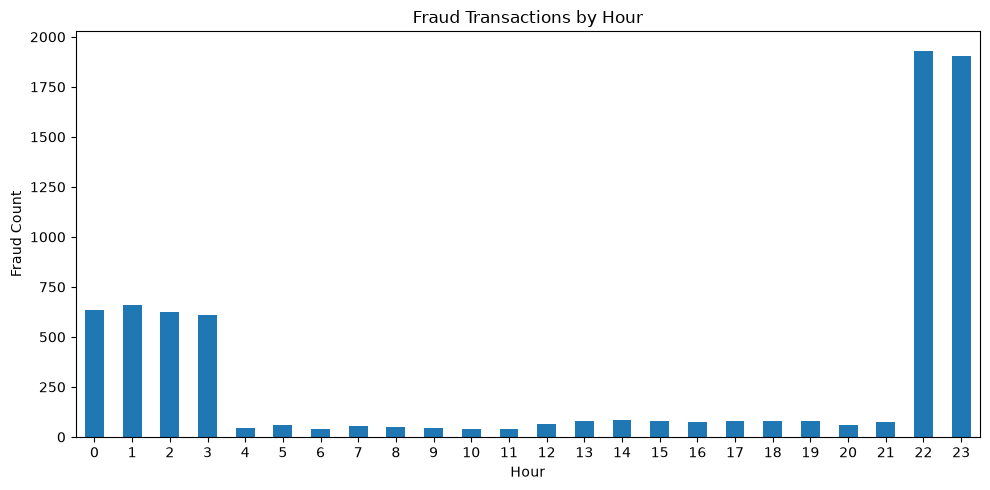

In [48]:
plt.figure(figsize=(10,5))

hour_fraud.plot(kind="bar")

plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Count")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [49]:
# 시간(hour) 추출
df["hour"] = df["trans_date_trans_time"].dt.hour

In [50]:
hourly_fraud_df = (
    df[df["is_fraud"] == 1]
      .groupby("hour")
      .size()
      .reset_index(name="fraud_count")
)

hourly_fraud_df

,hour,fraud_count
0,0,635
1,1,658
2,2,625
3,3,609
4,4,46
5,5,60
6,6,40
7,7,56
8,8,49
9,9,47


In [51]:
# 고유 고객 수
num_customers = df["cc_num"].nunique()

print(f"총 거래 참여 고객 수: {num_customers:,}명")

총 거래 참여 고객 수: 983명


In [52]:
customer_tx = (
    df.groupby("cc_num")
      .size()
      .reset_index(name="transaction_count")
)

customer_tx

,cc_num,transaction_count
0,60416207185,1518
1,60422928733,1531
2,60423098130,510
3,60427851591,528
4,60487002085,496
...,...,...
978,4958589671582726883,1476
979,4973530368125489546,1040
980,4980323467523543940,532
981,4989847570577635369,1007


In [53]:
display(customer_tx)


,cc_num,transaction_count
0,60416207185,1518
1,60422928733,1531
2,60423098130,510
3,60427851591,528
4,60487002085,496
...,...,...
978,4958589671582726883,1476
979,4973530368125489546,1040
980,4980323467523543940,532
981,4989847570577635369,1007


In [54]:
customer_tx.sort_values(
    by="transaction_count",
    ascending=False
).head(20)

,cc_num,transaction_count
28,571365235126,3123
943,4512828414983801773,3123
222,36722699017270,3119
272,213112402583773,3117
531,3545109339866548,3113
869,6534628260579800,3112
822,6011367958204270,3110
452,2720433095629877,3107
828,6011438889172900,3106
811,6011109736646996,3101


In [55]:
customer_tx["transaction_count"].describe()

count     983.000000
mean     1319.099695
std       812.235900
min         7.000000
25%       525.000000
50%      1054.000000
75%      2025.000000
max      3123.000000
Name: transaction_count, dtype: float64

In [56]:
fraud_customers_df = (
    df[df["is_fraud"] == 1][["cc_num"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

fraud_customers_df


,cc_num
0,4613314721966
1,340187018810220
2,4922710831011201
3,341546199006537
4,30328384440870
...,...
757,3573030041201292
758,3560725013359375
759,6564459919350820
760,3524574586339330


In [57]:
display(fraud_customers_df)


,cc_num
0,4613314721966
1,340187018810220
2,4922710831011201
3,341546199006537
4,30328384440870
...,...
757,3573030041201292
758,3560725013359375
759,6564459919350820
760,3524574586339330


In [58]:
# 이상거래가 발생한 고객 목록
fraud_customers = (
    df[df["is_fraud"] == 1]["cc_num"]
    .drop_duplicates()
    .reset_index(drop=True)
)

fraud_customers

0         4613314721966
1       340187018810220
2      4922710831011201
3       341546199006537
4        30328384440870
             ...       
757    3573030041201292
758    3560725013359375
759    6564459919350820
760    3524574586339330
761    4005676619255478
Name: cc_num, Length: 762, dtype: int64

In [59]:
customer_total = (
    df.groupby("cc_num")
      .size()
      .reset_index(name="total_transactions")
)

In [60]:
customer_fraud = (
    df[df["is_fraud"] == 1]
      .groupby("cc_num")
      .size()
      .reset_index(name="fraud_transactions")
)

In [61]:
customer_summary = customer_total.merge(
    customer_fraud,
    on="cc_num",
    how="left"
)

customer_summary["fraud_transactions"] = (
    customer_summary["fraud_transactions"]
    .fillna(0)
    .astype(int)
)

customer_summary["fraud_rate(%)"] = (
    customer_summary["fraud_transactions"]
    / customer_summary["total_transactions"]
    * 100
).round(2)

customer_summary

,cc_num,total_transactions,fraud_transactions,fraud_rate(%)
0,60416207185,1518,9,0.59
1,60422928733,1531,12,0.78
2,60423098130,510,10,1.96
3,60427851591,528,14,2.65
4,60487002085,496,0,0.00
...,...,...,...,...
978,4958589671582726883,1476,0,0.00
979,4973530368125489546,1040,10,0.96
980,4980323467523543940,532,10,1.88
981,4989847570577635369,1007,0,0.00


In [62]:
display(customer_summary)


,cc_num,total_transactions,fraud_transactions,fraud_rate(%)
0,60416207185,1518,9,0.59
1,60422928733,1531,12,0.78
2,60423098130,510,10,1.96
3,60427851591,528,14,2.65
4,60487002085,496,0,0.00
...,...,...,...,...
978,4958589671582726883,1476,0,0.00
979,4973530368125489546,1040,10,0.96
980,4980323467523543940,532,10,1.88
981,4989847570577635369,1007,0,0.00


In [63]:
customer_summary.sort_values(
    by="fraud_rate(%)",
    ascending=False
)

,cc_num,total_transactions,fraud_transactions,fraud_rate(%)
105,4457486401506,10,10,100.0
937,4481172224716138389,8,8,100.0
532,3545578418030657,7,7,100.0
533,3546436741611231,12,12,100.0
76,676327197445,8,8,100.0
...,...,...,...,...
367,375248307838179,2053,0,0.0
365,375082648741747,2048,0,0.0
623,3596217206093829,3051,0,0.0
361,374497717543058,2041,0,0.0


In [64]:
# 전체 고유 가맹점 수
num_merchants = df["merchant"].nunique()

print(f"전체 가맹점 수 : {num_merchants:,}개")

전체 가맹점 수 : 693개


In [65]:
# 전체 고유 가맹점 수
num_merchants = df["merchant"].nunique()

print(f"전체 가맹점 수 : {num_merchants:,}개")

전체 가맹점 수 : 693개


In [66]:
# 이상거래가 발생한 고유 가맹점 수
fraud_merchants = (
    df[df["is_fraud"] == 1]["merchant"]
    .nunique()
)

print(f"이상거래가 발생한 가맹점 수 : {fraud_merchants:,}개")

이상거래가 발생한 가맹점 수 : 679개


In [67]:
fraud_merchant_list = (
    df[df["is_fraud"] == 1][["merchant"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

fraud_merchant_list

,merchant
0,fraud_Rutherford-Mertz
1,"fraud_Jenkins, Hauck and Friesen"
2,fraud_Goodwin-Nitzsche
3,fraud_Erdman-Kertzmann
4,fraud_Koepp-Parker
...,...
674,fraud_Torphy-Kertzmann
675,"fraud_Kohler, Lindgren and Koelpin"
676,fraud_Connelly PLC
677,fraud_Fadel Inc


In [68]:
display(fraud_merchant_list)


,merchant
0,fraud_Rutherford-Mertz
1,"fraud_Jenkins, Hauck and Friesen"
2,fraud_Goodwin-Nitzsche
3,fraud_Erdman-Kertzmann
4,fraud_Koepp-Parker
...,...
674,fraud_Torphy-Kertzmann
675,"fraud_Kohler, Lindgren and Koelpin"
676,fraud_Connelly PLC
677,fraud_Fadel Inc


In [69]:
merchant_fraud_count = (
    df[df["is_fraud"] == 1]
    .groupby("merchant")
    .size()
    .reset_index(name="fraud_count")
    .sort_values(by="fraud_count", ascending=False)
)

merchant_fraud_count

,merchant,fraud_count
486,fraud_Rau and Sons,49
334,fraud_Kozey-Boehm,48
105,fraud_Cormier LLC,48
146,fraud_Doyle Ltd,47
632,fraud_Vandervort-Funk,47
...,...,...
135,fraud_Dicki Ltd,1
353,fraud_Kuphal-Toy,1
129,fraud_Deckow-Dare,1
120,fraud_Dach-Borer,1


In [70]:
# 전체 거래 횟수
merchant_total = (
    df.groupby("merchant")
      .size()
      .reset_index(name="total_transactions")
)

# 이상거래 횟수
merchant_fraud = (
    df[df["is_fraud"] == 1]
      .groupby("merchant")
      .size()
      .reset_index(name="fraud_transactions")
)

# 병합
merchant_summary = merchant_total.merge(
    merchant_fraud,
    on="merchant",
    how="left"
)

# 결측치 처리
merchant_summary["fraud_transactions"] = (
    merchant_summary["fraud_transactions"]
    .fillna(0)
    .astype(int)
)

# 이상거래 발생률
merchant_summary["fraud_rate(%)"] = (
    merchant_summary["fraud_transactions"]
    / merchant_summary["total_transactions"]
    * 100
).round(3)

# 이상거래 발생률 → 이상거래 건수 순으로 정렬
merchant_summary = merchant_summary.sort_values(
    by=["fraud_rate(%)", "fraud_transactions"],
    ascending=[False, False]
)

merchant_summary

,merchant,total_transactions,fraud_transactions,fraud_rate(%)
337,fraud_Kozey-Boehm,1866,48,2.572
245,"fraud_Herman, Treutel and Dickens",1300,33,2.538
304,fraud_Kerluke-Abshire,1838,41,2.231
79,fraud_Brown PLC,1176,26,2.211
200,fraud_Goyette Inc,1943,42,2.162
...,...,...,...,...
516,"fraud_Ritchie, Bradtke and Stiedemann",786,0,0.000
527,fraud_Romaguera and Sons,838,0,0.000
566,fraud_Schroeder Group,1675,0,0.000
568,"fraud_Schroeder, Wolff and Hermiston",825,0,0.000


In [71]:
display(merchant_summary)


,merchant,total_transactions,fraud_transactions,fraud_rate(%)
337,fraud_Kozey-Boehm,1866,48,2.572
245,"fraud_Herman, Treutel and Dickens",1300,33,2.538
304,fraud_Kerluke-Abshire,1838,41,2.231
79,fraud_Brown PLC,1176,26,2.211
200,fraud_Goyette Inc,1943,42,2.162
...,...,...,...,...
516,"fraud_Ritchie, Bradtke and Stiedemann",786,0,0.000
527,fraud_Romaguera and Sons,838,0,0.000
566,fraud_Schroeder Group,1675,0,0.000
568,"fraud_Schroeder, Wolff and Hermiston",825,0,0.000


In [72]:
category_ratio = (
    df["category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

category_ratio.columns = ["category", "ratio(%)"]

category_ratio

,category,ratio(%)
0,gas_transport,10.15
1,grocery_pos,9.54
2,home,9.49
3,shopping_pos,9.00
4,kids_pets,8.72
5,shopping_net,7.52
6,entertainment,7.25
7,food_dining,7.05
8,personal_care,7.00
9,health_fitness,6.62


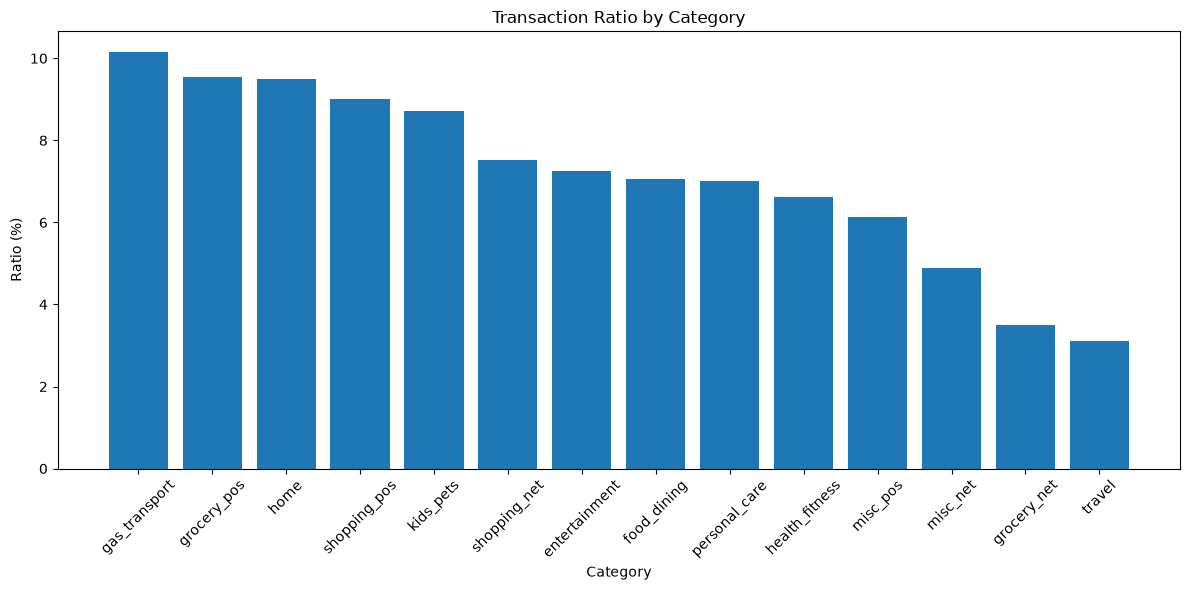

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    category_ratio["category"],
    category_ratio["ratio(%)"]
)

plt.xticks(rotation=45)

plt.xlabel("Category")
plt.ylabel("Ratio (%)")
plt.title("Transaction Ratio by Category")

plt.tight_layout()

plt.show()

In [74]:
!pip install squarify


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


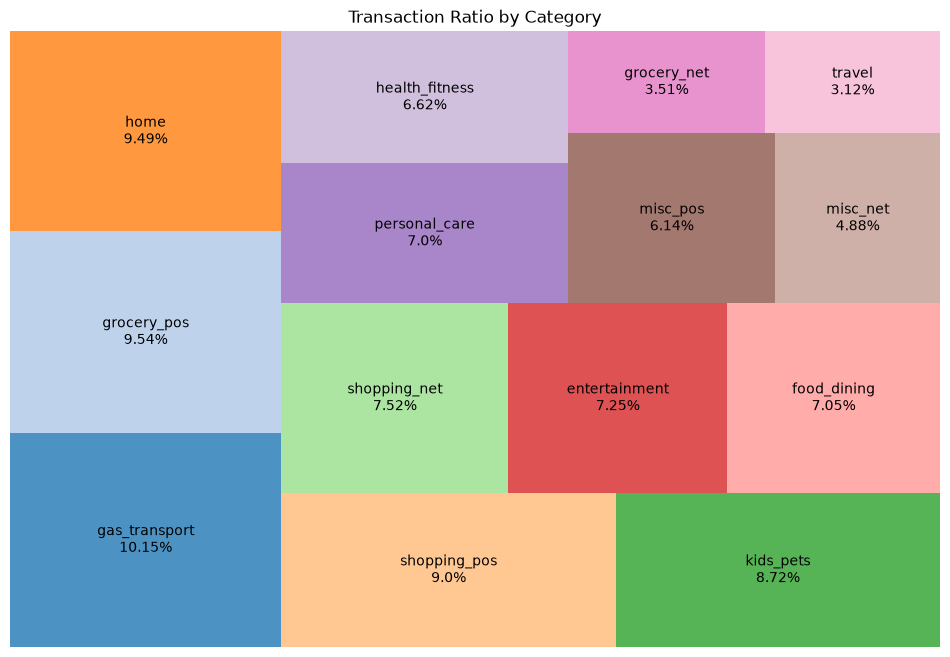

In [75]:
import squarify
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.figure(figsize=(12,8))

cmap = mpl.colormaps["tab20"]
colors = [cmap(i % cmap.N) for i in range(len(category_ratio))]

squarify.plot(
    sizes=category_ratio["ratio(%)"],
    label=category_ratio["category"] +
          "\n" +
          category_ratio["ratio(%)"].astype(str)+"%",
    color=colors,
    alpha=0.8
)

plt.axis("off")
plt.title("Transaction Ratio by Category")

plt.show()

In [76]:
category_fraud = (
    df[df["is_fraud"]==1]
    .groupby("category")
    .size()
    .reset_index(name="fraud_count")
    .sort_values(
        by="fraud_count",
        ascending=False
    )
)

category_fraud

,category,fraud_count
4,grocery_pos,1743
11,shopping_net,1713
8,misc_net,915
12,shopping_pos,843
2,gas_transport,618
9,misc_pos,250
7,kids_pets,239
0,entertainment,233
10,personal_care,220
6,home,198


In [77]:
category_summary = (
    df.groupby("category")
      .agg(
          total_transactions=("is_fraud","count"),
          fraud_transactions=("is_fraud","sum")
      )
      .reset_index()
)

category_summary["fraud_rate(%)"] = (
    category_summary["fraud_transactions"]
    / category_summary["total_transactions"]
    *100
).round(3)

category_summary = category_summary.sort_values(
    by="fraud_rate(%)",
    ascending=False
)

category_summary

,category,total_transactions,fraud_transactions,fraud_rate(%)
11,shopping_net,97543,1713,1.756
8,misc_net,63287,915,1.446
4,grocery_pos,123638,1743,1.410
12,shopping_pos,116672,843,0.723
2,gas_transport,131659,618,0.469
9,misc_pos,79655,250,0.314
3,grocery_net,45452,134,0.295
13,travel,40507,116,0.286
0,entertainment,94014,233,0.248
10,personal_care,90758,220,0.242


In [78]:
display(category_summary)


,category,total_transactions,fraud_transactions,fraud_rate(%)
11,shopping_net,97543,1713,1.756
8,misc_net,63287,915,1.446
4,grocery_pos,123638,1743,1.410
12,shopping_pos,116672,843,0.723
2,gas_transport,131659,618,0.469
9,misc_pos,79655,250,0.314
3,grocery_net,45452,134,0.295
13,travel,40507,116,0.286
0,entertainment,94014,233,0.248
10,personal_care,90758,220,0.242


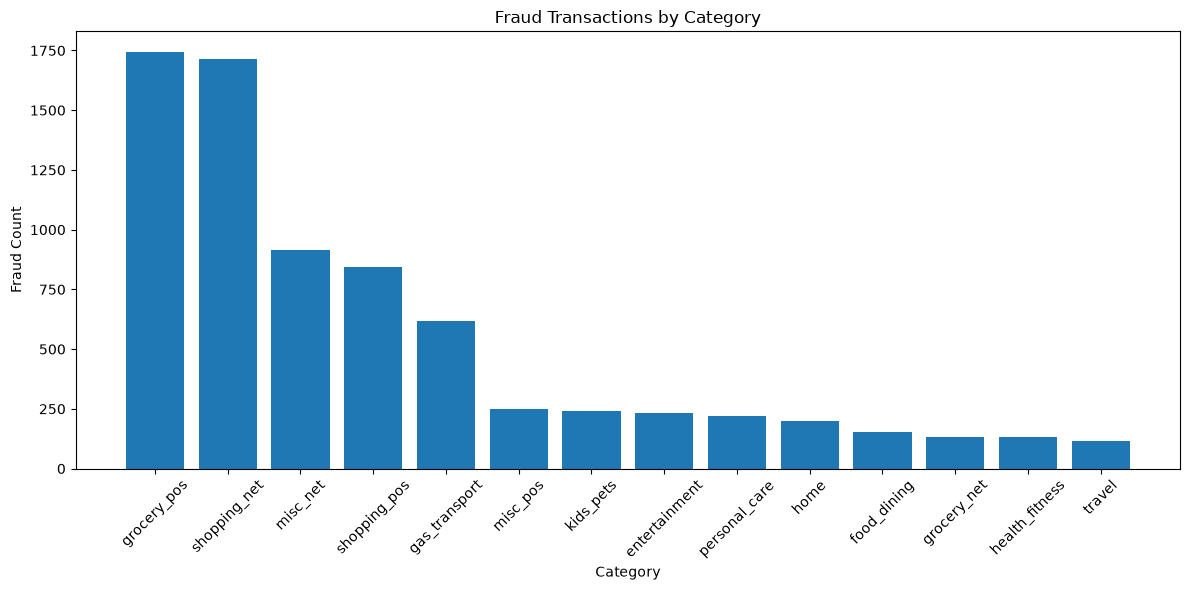

In [79]:
plt.figure(figsize=(12,6))

plt.bar(
    category_fraud["category"],
    category_fraud["fraud_count"]
)

plt.xticks(rotation=45)

plt.xlabel("Category")
plt.ylabel("Fraud Count")

plt.title("Fraud Transactions by Category")

plt.tight_layout()

plt.show()

In [80]:
df["amt"].describe().round(2)

count    1296675.00
mean          70.35
std          160.32
min            1.00
25%            9.65
50%           47.52
75%           83.14
max        28948.90
Name: amt, dtype: float64

In [81]:
import numpy as np
import pandas as pd

# 0~500까지 50달러 간격
bins = list(range(0, 501, 50))
bins.append(df["amt"].max())   # 마지막은 최대값

labels = [
    "0~50",
    "51~100",
    "101~150",
    "151~200",
    "201~250",
    "251~300",
    "301~350",
    "351~400",
    "401~450",
    "451~500",
    "500+"
]

df["amt_group"] = pd.cut(
    df["amt"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [82]:
bins = [0,10,20,50,100,200,500,1000,5000,100000]

labels = [
    "0~10",
    "10~20",
    "20~50",
    "50~100",
    "100~200",
    "200~500",
    "500~1000",
    "1000~5000",
    "5000+"
]

df["amt_group"] = pd.cut(
    df["amt"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [83]:
amount_count = (
    df.groupby("amt_group", observed=True)
      .size()
      .reset_index(name="transaction_count")
)

amount_count


,amt_group,transaction_count
0,0~10,335929
1,10~20,88500
2,20~50,247870
3,50~100,389483
4,100~200,172969
5,200~500,46293
6,500~1000,11695
7,1000~5000,3800
8,5000+,136


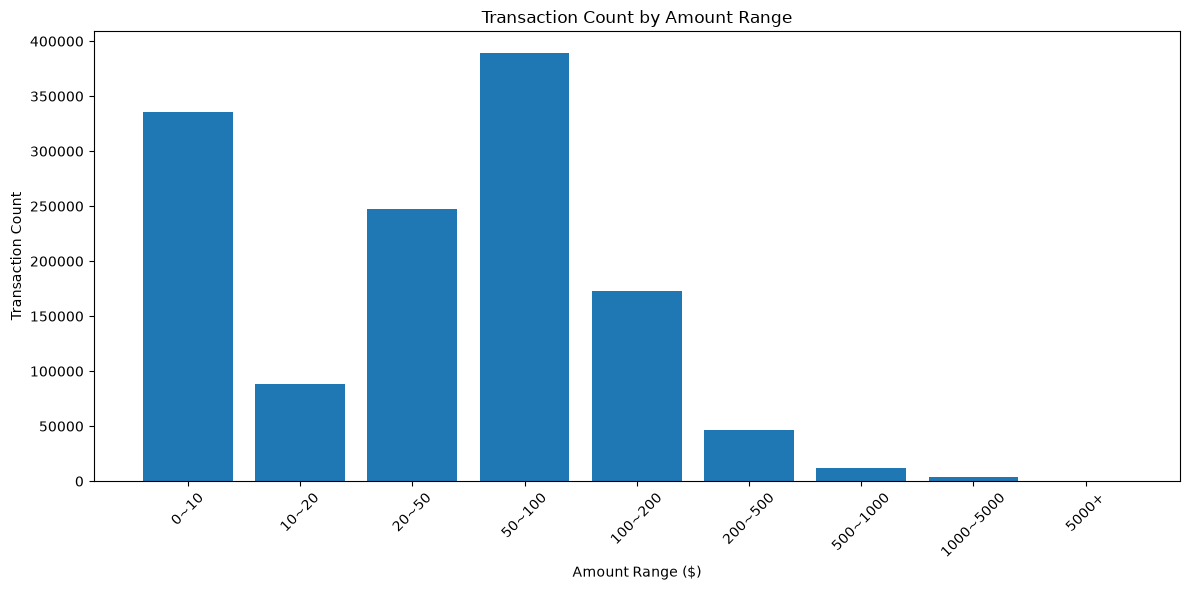

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    amount_count["amt_group"].astype(str),
    amount_count["transaction_count"]
)

plt.title("Transaction Count by Amount Range")
plt.xlabel("Amount Range ($)")
plt.ylabel("Transaction Count")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [85]:
fraud_amount = (
    df[df["is_fraud"] == 1]
      .groupby("amt_group", observed=True)
      .size()
      .reset_index(name="fraud_count")
)

fraud_amount

,amt_group,fraud_count
0,0~10,525
1,10~20,722
2,20~50,360
3,50~100,45
4,100~200,150
5,200~500,2056
6,500~1000,2699
7,1000~5000,949


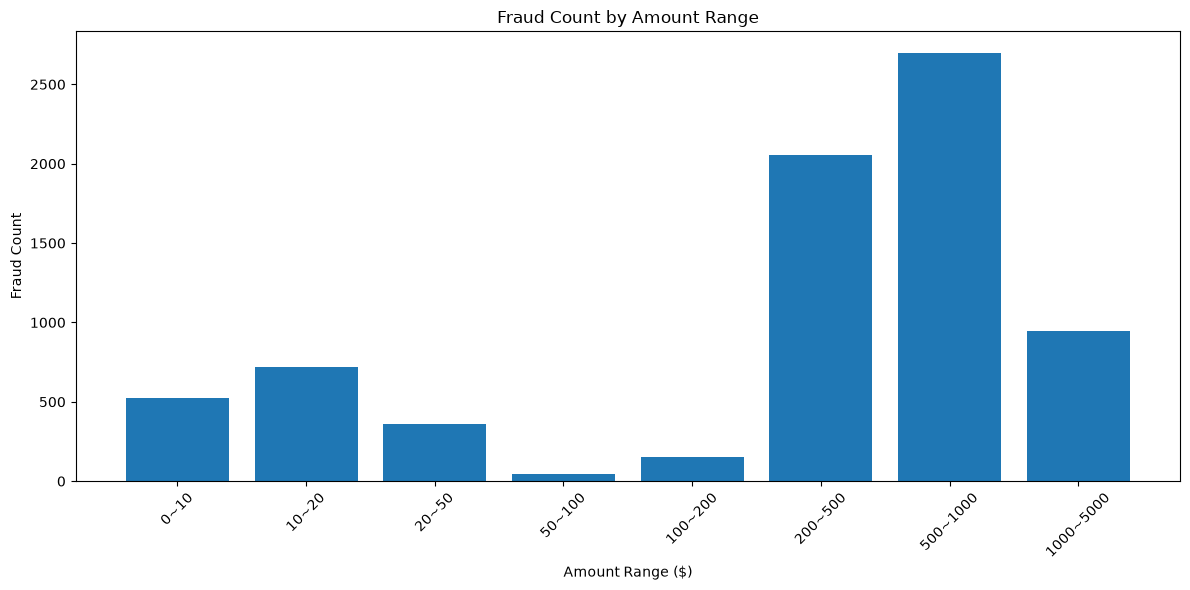

In [86]:
plt.figure(figsize=(12,6))

plt.bar(
    fraud_amount["amt_group"].astype(str),
    fraud_amount["fraud_count"]
)

plt.title("Fraud Count by Amount Range")
plt.xlabel("Amount Range ($)")
plt.ylabel("Fraud Count")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [87]:
amount_summary = (
    df.groupby("amt_group", observed=True)
      .agg(
          total_transactions=("is_fraud", "count"),
          fraud_transactions=("is_fraud", "sum")
      )
      .reset_index()
)

amount_summary["fraud_rate(%)"] = (
    amount_summary["fraud_transactions"]
    / amount_summary["total_transactions"]
    * 100
).round(2)

amount_summary

,amt_group,total_transactions,fraud_transactions,fraud_rate(%)
0,0~10,335929,525,0.16
1,10~20,88500,722,0.82
2,20~50,247870,360,0.15
3,50~100,389483,45,0.01
4,100~200,172969,150,0.09
5,200~500,46293,2056,4.44
6,500~1000,11695,2699,23.08
7,1000~5000,3800,949,24.97
8,5000+,136,0,0.00


In [88]:
# 가격대별 거래 건수와 이상거래 건수 집계
amount_summary = (
    df.groupby("amt_group", observed=True)
      .agg(
          total_transactions=("is_fraud", "count"),
          fraud_transactions=("is_fraud", "sum")
      )
      .reset_index()
)

# 이상거래 발생률(%)
amount_summary["fraud_rate(%)"] = (
    amount_summary["fraud_transactions"]
    / amount_summary["total_transactions"]
    * 100
).round(3)

amount_summary

,amt_group,total_transactions,fraud_transactions,fraud_rate(%)
0,0~10,335929,525,0.156
1,10~20,88500,722,0.816
2,20~50,247870,360,0.145
3,50~100,389483,45,0.012
4,100~200,172969,150,0.087
5,200~500,46293,2056,4.441
6,500~1000,11695,2699,23.078
7,1000~5000,3800,949,24.974
8,5000+,136,0,0.000


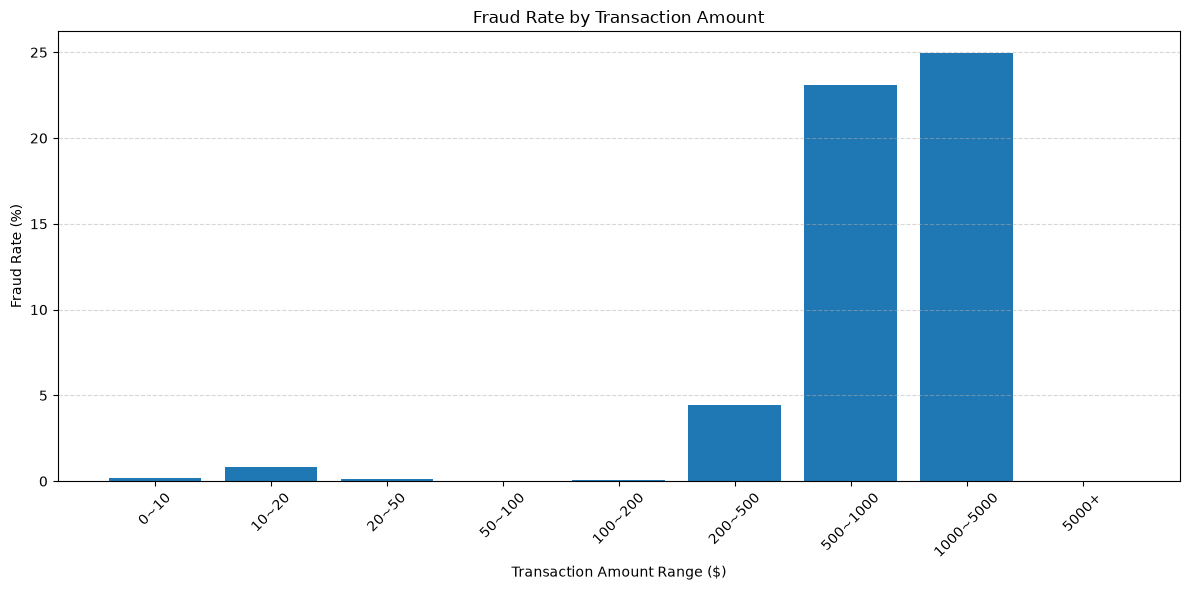

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    amount_summary["amt_group"].astype(str),
    amount_summary["fraud_rate(%)"]
)

plt.title("Fraud Rate by Transaction Amount")
plt.xlabel("Transaction Amount Range ($)")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)

# y축 격자 추가
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [90]:
amount_summary.sort_values(
    by="fraud_rate(%)",
    ascending=False
)

,amt_group,total_transactions,fraud_transactions,fraud_rate(%)
7,1000~5000,3800,949,24.974
6,500~1000,11695,2699,23.078
5,200~500,46293,2056,4.441
1,10~20,88500,722,0.816
0,0~10,335929,525,0.156
2,20~50,247870,360,0.145
4,100~200,172969,150,0.087
3,50~100,389483,45,0.012
8,5000+,136,0,0.000


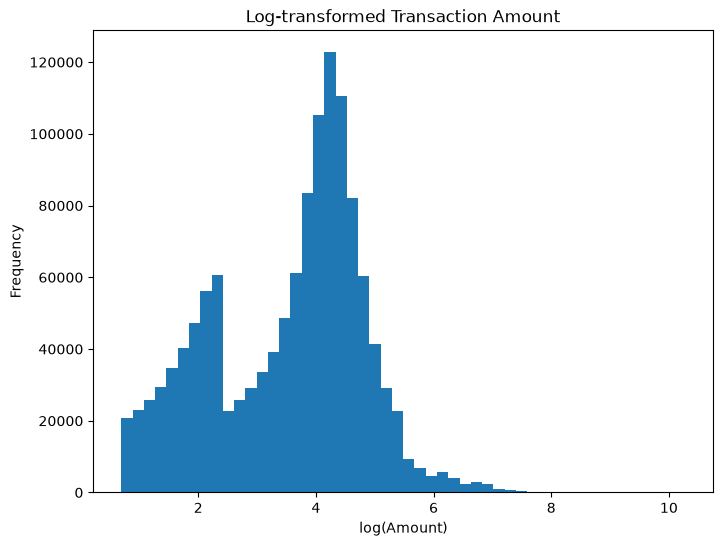

In [91]:
import numpy as np

df["log_amt"] = np.log1p(df["amt"])

plt.figure(figsize=(8,6))
plt.hist(df["log_amt"], bins=50)
plt.title("Log-transformed Transaction Amount")
plt.xlabel("log(Amount)")
plt.ylabel("Frequency")
plt.show()

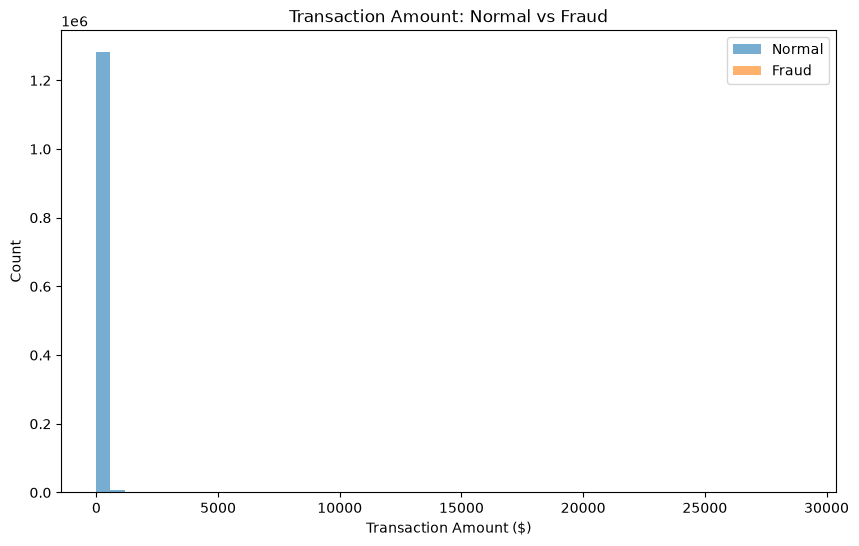

In [92]:
plt.figure(figsize=(10,6))

plt.hist(
    df[df["is_fraud"]==0]["amt"],
    bins=50,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    df[df["is_fraud"]==1]["amt"],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.legend()
plt.xlabel("Transaction Amount ($)")
plt.ylabel("Count")
plt.title("Transaction Amount: Normal vs Fraud")

plt.show()

In [93]:
# 카드별 평균 거래금액
df["customer_mean_amt"] = (
    df.groupby("cc_num")["amt"]
      .transform("mean")
)

df[["cc_num","amt","customer_mean_amt"]].head()

,cc_num,amt,customer_mean_amt
0,2703186189652095,4.97,87.393215
1,630423337322,107.23,53.949320
2,38859492057661,220.11,65.870040
3,3534093764340240,45.00,72.776673
4,375534208663984,41.96,95.178091


In [94]:
customer_summary = (
    df.groupby("cc_num")
      .agg(
          transaction_count=("amt", "count"),
          mean_amt=("amt", "mean"),
          std_amt=("amt", "std"),
          total_amt=("amt", "sum")
      )
      .reset_index()
)

customer_summary

,cc_num,transaction_count,mean_amt,std_amt,total_amt
0,60416207185,1518,56.023366,122.632635,85043.47
1,60422928733,1531,69.000784,102.681962,105640.20
2,60423098130,510,115.046333,1202.988005,58673.63
3,60427851591,528,111.987898,143.310653,59129.61
4,60487002085,496,50.726028,65.843969,25160.11
...,...,...,...,...,...
978,4958589671582726883,1476,66.377839,151.649600,97973.69
979,4973530368125489546,1040,78.373288,299.269322,81508.22
980,4980323467523543940,532,74.436429,130.051516,39600.18
981,4989847570577635369,1007,87.582542,122.908864,88195.62


In [95]:
display(customer_summary)


,cc_num,transaction_count,mean_amt,std_amt,total_amt
0,60416207185,1518,56.023366,122.632635,85043.47
1,60422928733,1531,69.000784,102.681962,105640.20
2,60423098130,510,115.046333,1202.988005,58673.63
3,60427851591,528,111.987898,143.310653,59129.61
4,60487002085,496,50.726028,65.843969,25160.11
...,...,...,...,...,...
978,4958589671582726883,1476,66.377839,151.649600,97973.69
979,4973530368125489546,1040,78.373288,299.269322,81508.22
980,4980323467523543940,532,74.436429,130.051516,39600.18
981,4989847570577635369,1007,87.582542,122.908864,88195.62


In [96]:
df["amt_ratio_to_mean"] = (
    df["amt"]
    /
    df["customer_mean_amt"]
).round(3)

df[
    ["cc_num","amt","customer_mean_amt","amt_ratio_to_mean"]
].head()

,cc_num,amt,customer_mean_amt,amt_ratio_to_mean
0,2703186189652095,4.97,87.393215,0.057
1,630423337322,107.23,53.949320,1.988
2,38859492057661,220.11,65.870040,3.342
3,3534093764340240,45.00,72.776673,0.618
4,375534208663984,41.96,95.178091,0.441


<Figure size 800x600 with 0 Axes>

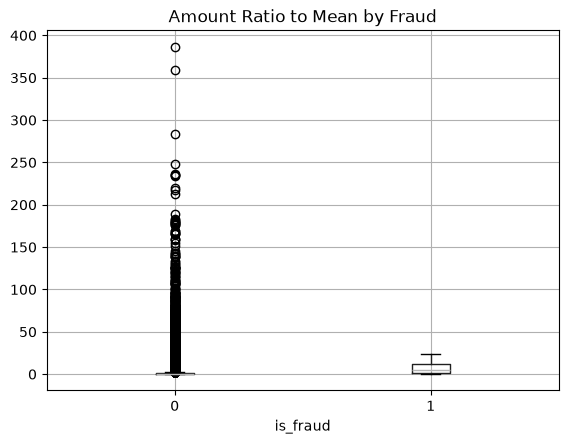

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

df.boxplot(
    column="amt_ratio_to_mean",
    by="is_fraud"
)

plt.title("Amount Ratio to Mean by Fraud")
plt.suptitle("")

plt.show()

In [98]:
df.groupby("is_fraud")["amt_ratio_to_mean"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,0.97,2.22,0.01,0.15,0.67,1.18,386.48
1,7506.0,6.91,5.88,0.01,1.03,5.18,12.38,23.91


In [99]:
df.groupby("is_fraud")["amt_ratio_to_mean"].median()

is_fraud
0    0.6660
1    5.1845
Name: amt_ratio_to_mean, dtype: float64

In [100]:
fraud_ratio = (
    df[df["is_fraud"]==1]
    .groupby("cc_num")
    .agg(
        fraud_count=("is_fraud","sum"),
        mean_ratio=("amt_ratio_to_mean","mean"),
        max_ratio=("amt_ratio_to_mean","max")
    )
    .sort_values(
        by="mean_ratio",
        ascending=False
    )
)

fraud_ratio

,fraud_count,mean_ratio,max_ratio
cc_num,,,
4653178848915023204,8,15.031125,18.200
2296006538441789,10,14.867700,22.641
4640395708703,5,14.311600,17.281
4839615922685395,8,14.181250,17.471
3547560454237873,7,14.167571,19.063
...,...,...,...
3528040995648998,11,0.999727,2.062
5104807169438134,8,0.903500,2.527
4069975342931683,3,0.209333,0.271


In [101]:
display(fraud_ratio.reset_index())

,cc_num,fraud_count,mean_ratio,max_ratio
0,4653178848915023204,8,15.031125,18.200
1,2296006538441789,10,14.867700,22.641
2,4640395708703,5,14.311600,17.281
3,4839615922685395,8,14.181250,17.471
4,3547560454237873,7,14.167571,19.063
...,...,...,...,...
757,3528040995648998,11,0.999727,2.062
758,5104807169438134,8,0.903500,2.527
759,4069975342931683,3,0.209333,0.271
760,4005676619255478,2,0.182500,0.183


In [102]:
# 이상거래를 1번이라도 경험한 고객 수
fraud_customer_count = df[df["is_fraud"] == 1]["cc_num"].nunique()

print("이상거래를 1번 이상 경험한 고객 수:", fraud_customer_count)

이상거래를 1번 이상 경험한 고객 수: 762


In [103]:
fraud_customer_summary = (
    df[df["is_fraud"] == 1]
    .groupby("cc_num")
    .size()
    .reset_index(name="fraud_count")
    .sort_values(by="fraud_count", ascending=False)
)

fraud_customer_summary

,cc_num,fraud_count
364,3520550088202337,19
89,4593569795412,19
73,4260128500325,18
121,30074693890476,16
340,2720433095629877,16
...,...,...
622,6011109736646996,2
733,4503101193493052864,2
460,3576431665303017,2
695,4089096483689733451,2


In [104]:
len(fraud_ratio)

762

In [105]:
df[df["is_fraud"] == 1]["cc_num"].nunique()

762

In [106]:
print("이상거래 고객 수 :", df[df["is_fraud"] == 1]["cc_num"].nunique())
print("fraud_ratio 행 수 :", len(fraud_ratio))

이상거래 고객 수 : 762
fraud_ratio 행 수 : 762


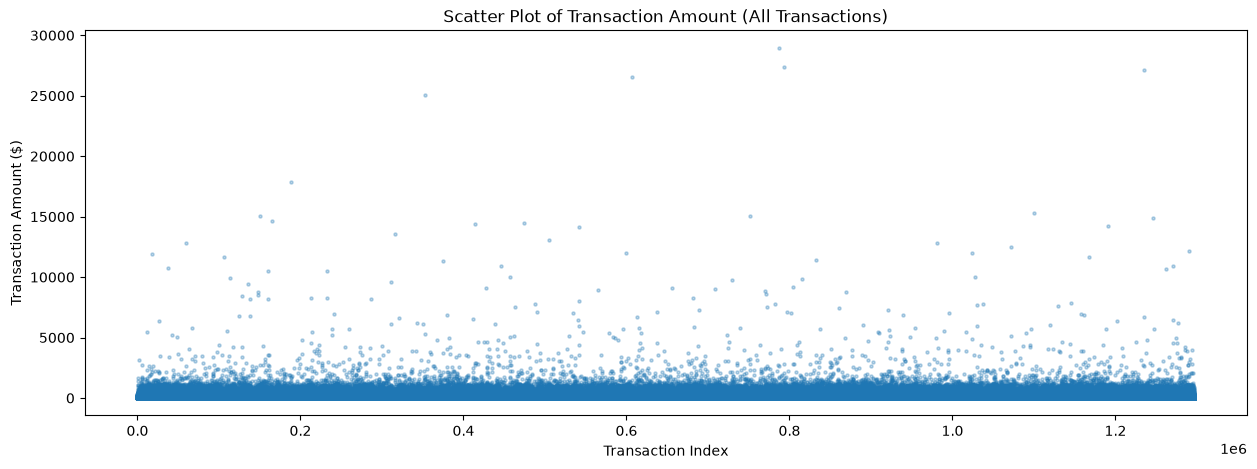

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.scatter(df.index, df["amt"], alpha=0.3, s=5)

plt.title("Scatter Plot of Transaction Amount (All Transactions)")
plt.xlabel("Transaction Index")
plt.ylabel("Transaction Amount ($)")

plt.show()

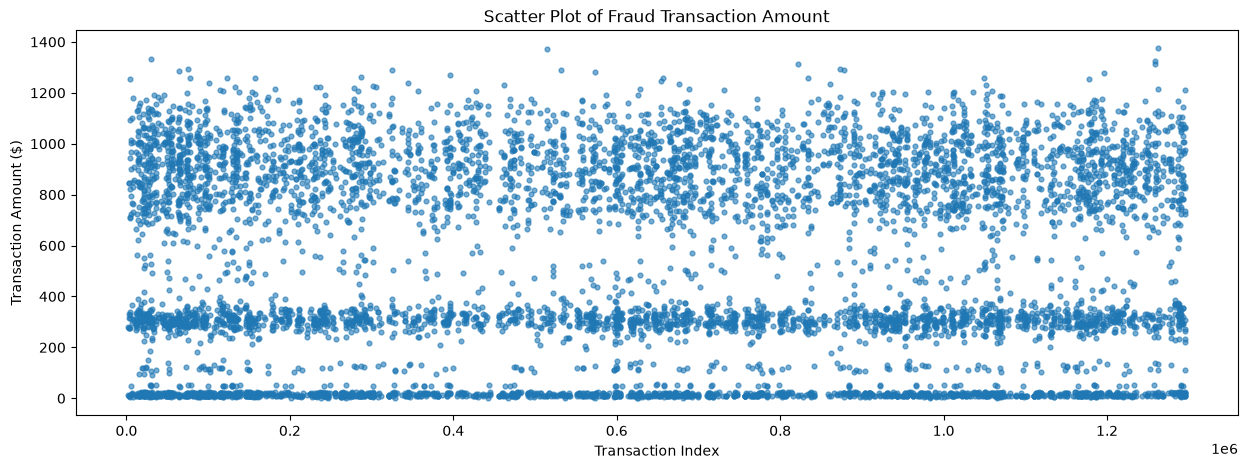

In [108]:
fraud_df = df[df["is_fraud"] == 1]

plt.figure(figsize=(15,5))

plt.scatter(fraud_df.index,
            fraud_df["amt"],
            alpha=0.6,
            s=12)

plt.title("Scatter Plot of Fraud Transaction Amount")
plt.xlabel("Transaction Index")
plt.ylabel("Transaction Amount ($)")

plt.show()

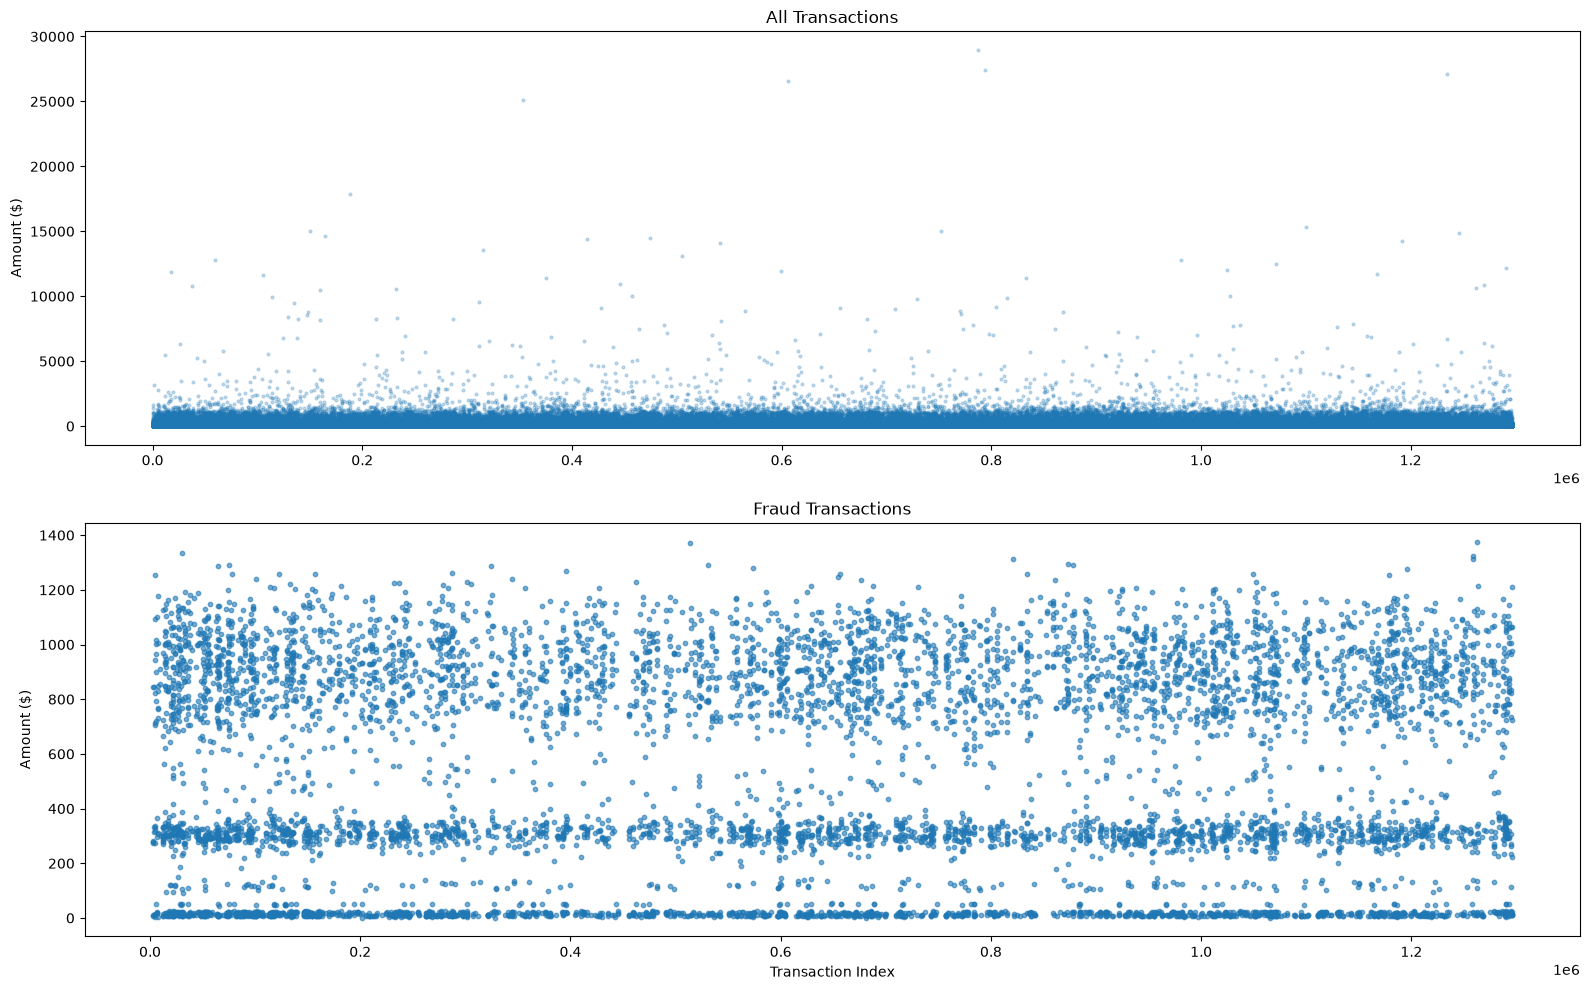

In [109]:
fig, ax = plt.subplots(2,1, figsize=(16,10))

# 전체 거래
ax[0].scatter(df.index,
              df["amt"],
              alpha=0.25,
              s=4)

ax[0].set_title("All Transactions")
ax[0].set_ylabel("Amount ($)")

# 이상거래
fraud_df = df[df["is_fraud"] == 1]

ax[1].scatter(fraud_df.index,
              fraud_df["amt"],
              alpha=0.6,
              s=10)

ax[1].set_title("Fraud Transactions")
ax[1].set_xlabel("Transaction Index")
ax[1].set_ylabel("Amount ($)")

plt.tight_layout()
plt.show()